# Análise Preditiva de RECEITA com Machine Learning

## Projeto de Projeção de RECEITA para os Últimos 6 Meses de 2022

⚠️ **CORREÇÃO CRÍTICA**: Este notebook foi atualizado para analisar **RECEITA EM USD**, não apenas quantidades vendidas.

### Objetivo Corrigido do Projeto

- **Problema**: Os dados de receita de 2022 estão incompletos (apenas janeiro-junho)
- **Solução**: Utilizar machine learning para prever a **receita em USD** dos meses restantes
- **Dados Integrados**: 
  - `Sales Data 2020-2022.csv`: Quantidades e chaves de produtos
  - `Product.csv`: **Preços em USD** (formato decimal com ponto: 13.0668)
- **Target**: **Total_Revenue_USD** = OrderQuantity × ProductPrice
- **Entrega**: Projeções de receita em USD para integração ao repositório

### Estrutura do Notebook

1. **Carregamento e Integração dos Dados** (Sales + Products)
2. **Cálculo da Receita Real** (Quantidade × Preço USD)
3. **Análise Exploratória da Receita**
4. **Feature Engineering para Receita**
5. **Modelagem e Treinamento**
6. **Avaliação do Modelo**
7. **Projeção da Receita Jul-Dez 2022**
8. **Visualização e Exportação dos Resultados**

### 🔧 Correções Técnicas Implementadas

- ✅ **JOIN** entre Sales Data e Product.csv
- ✅ **Cálculo de Receita**: Quantidade × Preço (USD)
- ✅ **Target corrigido**: Revenue_USD (não quantidade)
- ✅ **Features de Lag**: baseadas na receita histórica
- ✅ **Análise Monetária**: valores em dólares americanos

---

## 1. Importação das Bibliotecas Necessárias

Importamos todas as bibliotecas essenciais para análise de dados, machine learning e visualização:

In [1]:
# Bibliotecas para manipulação e análise de dados
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Bibliotecas para visualização
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Bibliotecas para machine learning
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Bibliotecas para séries temporais
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Configurações de exibição
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Todas as bibliotecas foram importadas com sucesso!")
print(f"📅 Data e hora de execução: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Todas as bibliotecas foram importadas com sucesso!
📅 Data e hora de execução: 2025-06-24 23:57:52


## 2. Carregamento e Pré-processamento dos Dados

⚠️ **CORREÇÃO IMPORTANTE**: Esta análise precisa considerar os **valores monetários** das vendas, não apenas quantidades. 

Vamos carregar:
- Dados de vendas históricos (2020, 2021, 2022) 
- **Product.csv** com preços em USD (formato decimal com ponto)
- Calcular receita real = Quantidade × Preço do Produto

**Objetivo**: Projetar **receita de vendas em USD** para jul-dez 2022.

In [2]:
# Carregamento dos dados de vendas e produtos
print("📂 Carregando dados de vendas e produtos...")

# Carregar dados de vendas dos anos 2020, 2021 e 2022
sales_2020 = pd.read_csv('Sales Data 2020.csv')
sales_2021 = pd.read_csv('Sales Data 2021.csv') 
sales_2022 = pd.read_csv('Sales Data 2022.csv')

# CRÍTICO: Carregar dados de produtos com preços em USD
products = pd.read_csv('Product.csv')

print(f"📊 Dados carregados:")
print(f"   • Sales 2020: {sales_2020.shape[0]:,} registros")
print(f"   • Sales 2021: {sales_2021.shape[0]:,} registros") 
print(f"   • Sales 2022: {sales_2022.shape[0]:,} registros")
print(f"   • Products: {products.shape[0]:,} produtos")

print(f"\n📋 Colunas Sales Data: {list(sales_2020.columns)}")
print(f"📋 Colunas Products: {list(products.columns)}")

# Verificar formato dos preços (USD com ponto decimal)
print(f"\n💰 Amostra de preços (USD):")
print(products[['ProductKey', 'ProductName', 'ProductPrice']].head())
print(f"   • Preço mínimo: ${products['ProductPrice'].min():.2f}")
print(f"   • Preço máximo: ${products['ProductPrice'].max():.2f}")

# Combinar todos os dados de vendas
sales_data = pd.concat([sales_2020, sales_2021, sales_2022], ignore_index=True)
print(f"\n🔗 Total de registros de vendas: {sales_data.shape[0]:,}")

# ETAPA CRÍTICA: Fazer JOIN com dados de produtos para obter preços
print(f"\n🔄 Fazendo JOIN entre Sales Data e Product Data...")
sales_with_prices = sales_data.merge(
    products[['ProductKey', 'ProductPrice', 'ProductName']], 
    on='ProductKey', 
    how='left'
)

# Verificar se o JOIN foi bem-sucedido
missing_products = sales_with_prices['ProductPrice'].isnull().sum()
print(f"   • Registros com preço: {len(sales_with_prices) - missing_products:,}")
print(f"   • Registros sem preço: {missing_products:,}")

if missing_products > 0:
    print(f"⚠️  ATENÇÃO: {missing_products} vendas sem preço identificado!")

# CALCULAR RECEITA REAL EM USD
sales_with_prices['Revenue_USD'] = sales_with_prices['OrderQuantity'] * sales_with_prices['ProductPrice']

print(f"\n💵 Receita calculada (USD):")
print(f"   • Receita total: ${sales_with_prices['Revenue_USD'].sum():,.2f}")
print(f"   • Receita média por pedido: ${sales_with_prices['Revenue_USD'].mean():.2f}")

sales_with_prices.head()

📂 Carregando dados de vendas e produtos...
📊 Dados carregados:
   • Sales 2020: 2,630 registros
   • Sales 2021: 23,935 registros
   • Sales 2022: 29,481 registros
   • Products: 293 produtos

📋 Colunas Sales Data: ['OrderDate', 'StockDate', 'OrderNumber', 'ProductKey', 'CustomerKey', 'TerritoryKey', 'OrderLineItem', 'OrderQuantity']
📋 Colunas Products: ['ProductKey', 'ProductSubcategoryKey', 'ProductSKU', 'ProductName', 'ModelName', 'ProductDescription', 'ProductColor', 'ProductSize', 'ProductStyle', 'ProductCost', 'ProductPrice']

💰 Amostra de preços (USD):
   ProductKey              ProductName  ProductPrice
0         214    Sport-100 Helmet, Red         34.99
1         215  Sport-100 Helmet, Black         33.64
2         218   Mountain Bike Socks, M          9.50
3         219   Mountain Bike Socks, L          9.50
4         220   Sport-100 Helmet, Blue         33.64
   • Preço mínimo: $2.29
   • Preço máximo: $3578.27

🔗 Total de registros de vendas: 56,046

🔄 Fazendo JOIN entre S

,OrderDate,StockDate,OrderNumber,ProductKey,CustomerKey,TerritoryKey,OrderLineItem,OrderQuantity,ProductPrice,ProductName,Revenue_USD
0,2020-01-01,2019-09-21,SO45080,332,14657,1,1,1,699.10,"Road-650 Black, 58",699.10
1,2020-01-01,2019-12-05,SO45079,312,29255,4,1,1,3578.27,"Road-150 Red, 48",3578.27
2,2020-01-01,2019-10-29,SO45082,350,11455,9,1,1,3374.99,"Mountain-100 Black, 44",3374.99
3,2020-01-01,2019-11-16,SO45081,338,26782,6,1,1,699.10,"Road-650 Black, 44",699.10
4,2020-01-02,2019-12-15,SO45083,312,14947,10,1,1,3578.27,"Road-150 Red, 48",3578.27


In [5]:
# Pré-processamento dos dados COM RECEITA
print("🔧 Iniciando pré-processamento dos dados COM RECEITA...")

# 1. Converter a coluna de data para datetime no dataset com preços
sales_with_prices['OrderDate'] = pd.to_datetime(sales_with_prices['OrderDate'])

# 2. Verificar valores ausentes no dataset integrado
print(f"❌ Valores ausentes por coluna (dados integrados):")
missing_values = sales_with_prices.isnull().sum()
print(missing_values[missing_values > 0])

# 3. Verificar duplicatas
duplicates = sales_with_prices.duplicated().sum()
print(f"🔄 Registros duplicados: {duplicates}")

# 4. Verificar faixa de datas
date_range = f"{sales_with_prices['OrderDate'].min().strftime('%Y-%m-%d')} até {sales_with_prices['OrderDate'].max().strftime('%Y-%m-%d')}"
print(f"📅 Período dos dados: {date_range}")

# 5. Verificar distribuição por ano
year_distribution = sales_with_prices['OrderDate'].dt.year.value_counts().sort_index()
print(f"\n📈 Distribuição por ano:")
for year, count in year_distribution.items():
    print(f"   • {year}: {count:,} registros")

# 6. Criar colunas de data auxiliares
sales_with_prices['Year'] = sales_with_prices['OrderDate'].dt.year
sales_with_prices['Month'] = sales_with_prices['OrderDate'].dt.month
sales_with_prices['YearMonth'] = sales_with_prices['OrderDate'].dt.to_period('M')

# 7. Verificar se temos receita calculada corretamente
print(f"\n💵 Verificação da Receita:")
print(f"   • Registros com receita válida: {sales_with_prices['Revenue_USD'].notna().sum():,}")
print(f"   • Receita mínima: ${sales_with_prices['Revenue_USD'].min():.2f}")
print(f"   • Receita máxima: ${sales_with_prices['Revenue_USD'].max():,.2f}")
print(f"   • Receita total: ${sales_with_prices['Revenue_USD'].sum():,.2f}")

print(f"\n✅ Pré-processamento concluído!")
print(f"📊 Formato final dos dados integrados: {sales_with_prices.shape}")

# Visualizar dados processados
sales_with_prices[['OrderDate', 'OrderQuantity', 'ProductPrice', 'Revenue_USD']].head()

🔧 Iniciando pré-processamento dos dados COM RECEITA...
❌ Valores ausentes por coluna (dados integrados):
Series([], dtype: int64)
🔄 Registros duplicados: 0
📅 Período dos dados: 2020-01-01 até 2022-06-30

📈 Distribuição por ano:
   • 2020: 2,630 registros
   • 2021: 23,935 registros
   • 2022: 29,481 registros

💵 Verificação da Receita:
   • Registros com receita válida: 56,046
   • Receita mínima: $2.29
   • Receita máxima: $3,578.27
   • Receita total: $24,914,586.82

✅ Pré-processamento concluído!
📊 Formato final dos dados integrados: (56046, 14)


,OrderDate,OrderQuantity,ProductPrice,Revenue_USD
0,2020-01-01,1,699.10,699.10
1,2020-01-01,1,3578.27,3578.27
2,2020-01-01,1,3374.99,3374.99
3,2020-01-01,1,699.10,699.10
4,2020-01-02,1,3578.27,3578.27


In [6]:
# Agregação dos dados por mês - AGORA COM RECEITA EM USD
print("💰 Criando agregações mensais de RECEITA (USD)...")

# Agregar RECEITA por mês (valor monetário real)
monthly_sales = sales_with_prices.groupby('YearMonth').agg({
    'Revenue_USD': ['sum', 'mean'],  # RECEITA TOTAL E MÉDIA
    'OrderQuantity': ['sum', 'mean'],  # Quantidades (para comparação)
    'OrderNumber': 'nunique',  # Pedidos únicos
    'ProductKey': 'nunique',  # Produtos únicos
    'CustomerKey': 'nunique',  # Clientes únicos
    'TerritoryKey': 'nunique'  # Territórios únicos
}).round(2)

# Simplificar nomes das colunas
monthly_sales.columns = [
    'Total_Revenue_USD', 'Avg_Revenue_USD',  # RECEITA em USD
    'Total_Quantity', 'Avg_Quantity',  # Quantidades
    'Unique_Orders', 'Unique_Products', 'Unique_Customers', 'Unique_Territories'
]

# Resetar index para facilitar manipulação
monthly_sales = monthly_sales.reset_index()
monthly_sales['Date'] = monthly_sales['YearMonth'].dt.to_timestamp()

# Criar colunas de tempo para features
monthly_sales['Year'] = monthly_sales['Date'].dt.year
monthly_sales['Month'] = monthly_sales['Date'].dt.month
monthly_sales['Month_Name'] = monthly_sales['Date'].dt.month_name()

# Calcular ticket médio
monthly_sales['Avg_Ticket_USD'] = monthly_sales['Total_Revenue_USD'] / monthly_sales['Unique_Orders']

print(f"💵 Dados mensais de RECEITA agregados: {monthly_sales.shape[0]} meses")
print(f"📅 Período: {monthly_sales['Date'].min().strftime('%Y-%m')} até {monthly_sales['Date'].max().strftime('%Y-%m')}")

# Verificar se temos dados completos até junho de 2022
max_date = monthly_sales['Date'].max()
print(f"🔍 Último mês com dados: {max_date.strftime('%Y-%m')}")

print(f"\n💰 Estatísticas de Receita (USD):")
print(f"   • Receita total período: ${monthly_sales['Total_Revenue_USD'].sum():,.2f}")
print(f"   • Receita média mensal: ${monthly_sales['Total_Revenue_USD'].mean():,.2f}")
print(f"   • Ticket médio geral: ${monthly_sales['Avg_Ticket_USD'].mean():.2f}")

# Visualizar dados agregados
print(f"\n📋 Amostra dos dados mensais (RECEITA EM USD):")
monthly_sales[['Date', 'Total_Revenue_USD', 'Total_Quantity', 'Unique_Orders', 'Avg_Ticket_USD']].head()

💰 Criando agregações mensais de RECEITA (USD)...
💵 Dados mensais de RECEITA agregados: 30 meses
📅 Período: 2020-01 até 2022-06
🔍 Último mês com dados: 2022-06

💰 Estatísticas de Receita (USD):
   • Receita total período: $24,914,586.84
   • Receita média mensal: $830,486.23
   • Ticket médio geral: $1667.18

📋 Amostra dos dados mensais (RECEITA EM USD):


,Date,Total_Revenue_USD,Total_Quantity,Unique_Orders,Avg_Ticket_USD
0,2020-01-01,585312.65,184,184,3181.05
1,2020-02-01,532226.25,165,165,3225.61
2,2020-03-01,643436.10,198,198,3249.68
3,2020-04-01,653364.04,204,204,3202.76
4,2020-05-01,659325.90,206,206,3200.61


## 3. Análise Exploratória dos Dados de Vendas

Vamos analisar o comportamento das vendas ao longo do tempo para identificar tendências, sazonalidades e padrões que ajudarão na construção do modelo preditivo.

💰 Estatísticas Descritivas da RECEITA MENSAL (USD)
       Total_Revenue_USD  Unique_Orders  Avg_Ticket_USD  Unique_Customers
count              30.00          30.00           30.00             30.00
mean           830486.23         838.80         1667.18            817.00
std            451317.34         794.44          918.64            766.01
min            326611.15         165.00          521.19            165.00
25%            504274.63         214.75          772.64            214.75
50%            648400.07         301.00         1710.49            301.00
75%           1107890.05        1667.50         1900.49           1602.25
max           1826987.14        2165.00         3249.68           2105.00


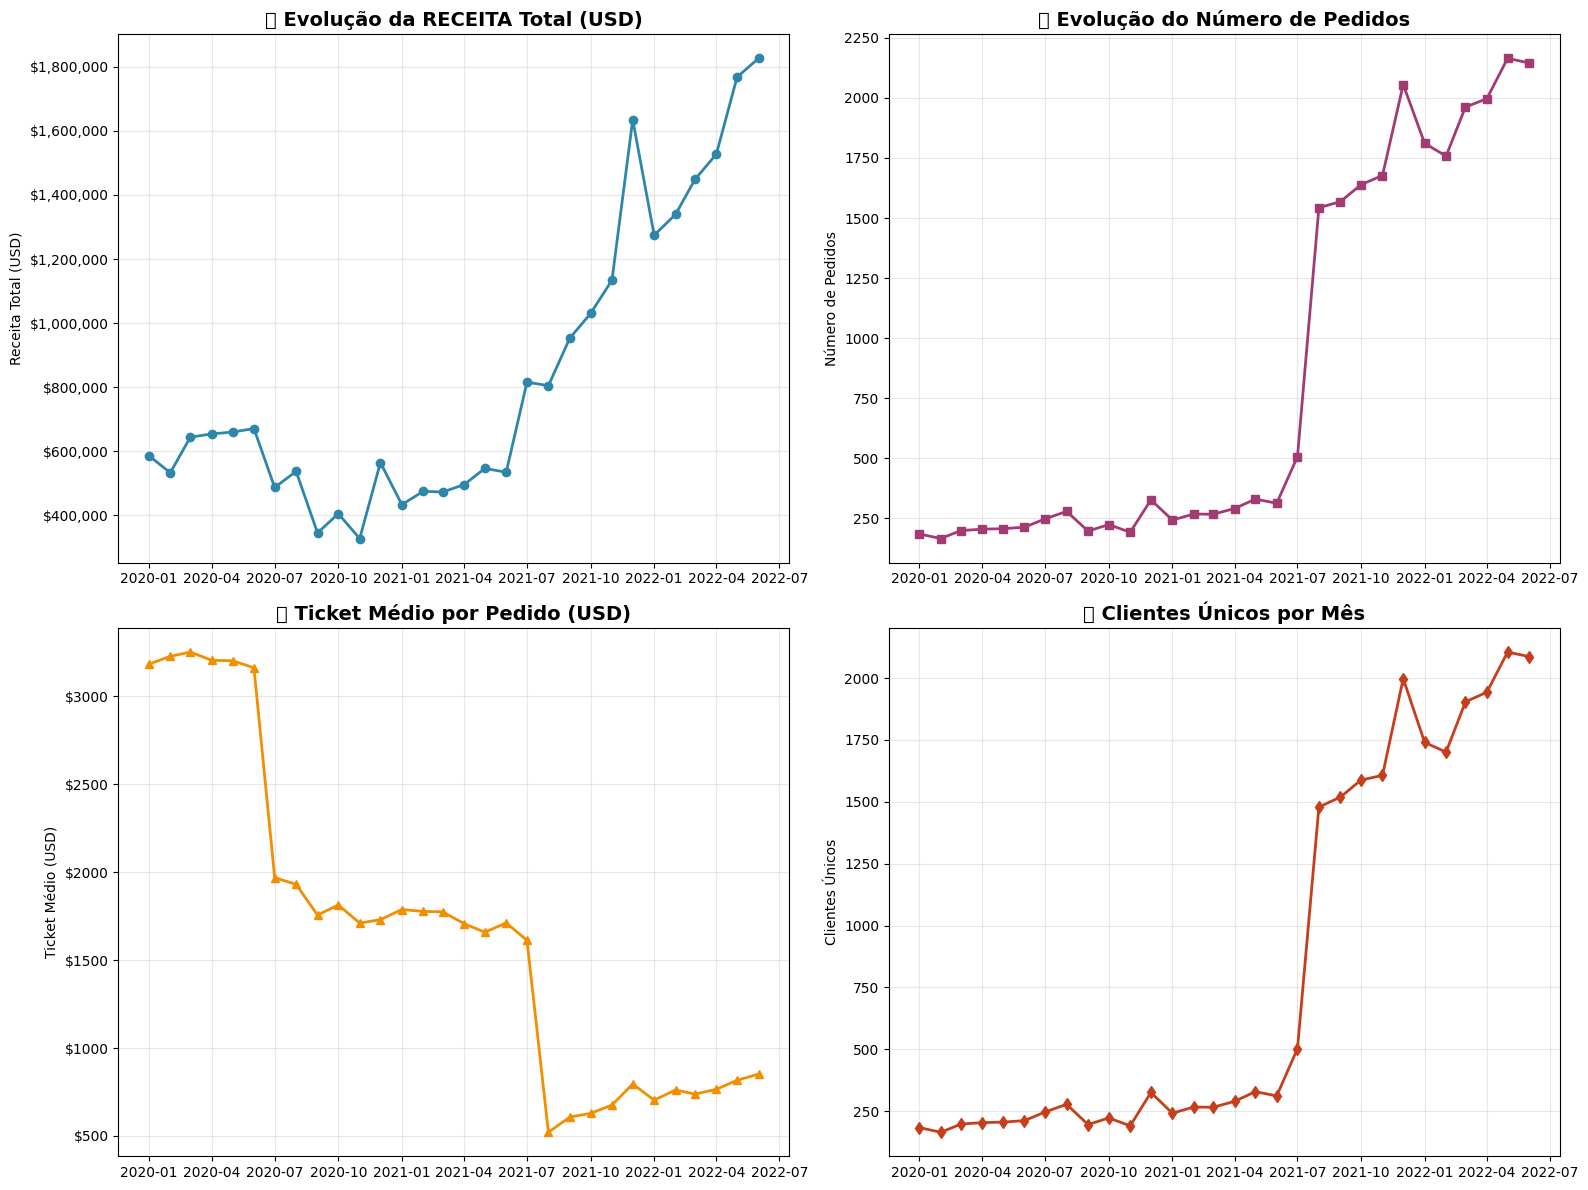


🗓️ Análise Sazonal por Mês do Ano (RECEITA USD)
       Receita_Média_USD  Receita_Desvio_USD  Ticket_Médio_USD  Pedidos_Média
Month                                                                        
1              764039.02           448529.29           1890.54         745.67
2              781876.78           483564.10           1921.10         730.00
3              854664.70           521456.37           1920.77         808.67
4              892045.06           556259.39           1891.52         830.33
5              991097.72           675591.70           1891.87         900.00
6             1010266.93           710569.53           1907.55         890.00
7              650735.74           232808.87           1789.73         376.50
8              670323.10           189321.17           1225.44         910.50
9              648403.18           430402.19           1181.52         882.00
10             717048.82           442326.72           1220.61         931.00
11             

In [7]:
# Estatísticas descritivas dos dados mensais - RECEITA EM USD
print("💰 Estatísticas Descritivas da RECEITA MENSAL (USD)")
print("="*60)
print(monthly_sales[['Total_Revenue_USD', 'Unique_Orders', 'Avg_Ticket_USD', 'Unique_Customers']].describe())

# Gráfico da série temporal de RECEITA
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. RECEITA TOTAL em USD por mês
axes[0,0].plot(monthly_sales['Date'], monthly_sales['Total_Revenue_USD'], 
               marker='o', linewidth=2, markersize=6, color='#2E86AB')
axes[0,0].set_title('💰 Evolução da RECEITA Total (USD)', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Receita Total (USD)')
axes[0,0].grid(True, alpha=0.3)
# Formatar eixo Y para valores monetários
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# 2. Número total de pedidos por mês
axes[0,1].plot(monthly_sales['Date'], monthly_sales['Unique_Orders'], 
               marker='s', linewidth=2, markersize=6, color='#A23B72')
axes[0,1].set_title('📋 Evolução do Número de Pedidos', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('Número de Pedidos')
axes[0,1].grid(True, alpha=0.3)

# 3. Ticket Médio em USD
axes[1,0].plot(monthly_sales['Date'], monthly_sales['Avg_Ticket_USD'], 
               marker='^', linewidth=2, markersize=6, color='#F18F01')
axes[1,0].set_title('🎫 Ticket Médio por Pedido (USD)', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('Ticket Médio (USD)')
axes[1,0].grid(True, alpha=0.3)
axes[1,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:.0f}'))

# 4. Clientes únicos por mês
axes[1,1].plot(monthly_sales['Date'], monthly_sales['Unique_Customers'], 
               marker='d', linewidth=2, markersize=6, color='#C73E1D')
axes[1,1].set_title('👥 Clientes Únicos por Mês', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel('Clientes Únicos')
axes[1,1].grid(True, alpha=0.3)

# Ajustar layout
plt.tight_layout()
plt.show()

# Análise sazonal por mês - RECEITA
print(f"\n🗓️ Análise Sazonal por Mês do Ano (RECEITA USD)")
print("="*50)
seasonal_analysis = monthly_sales.groupby('Month').agg({
    'Total_Revenue_USD': ['mean', 'std'],
    'Avg_Ticket_USD': 'mean',
    'Unique_Orders': 'mean'
}).round(2)

seasonal_analysis.columns = ['Receita_Média_USD', 'Receita_Desvio_USD', 'Ticket_Médio_USD', 'Pedidos_Média']
print(seasonal_analysis)

🔍 Decomposição Sazonal da Série Temporal de RECEITA (USD)


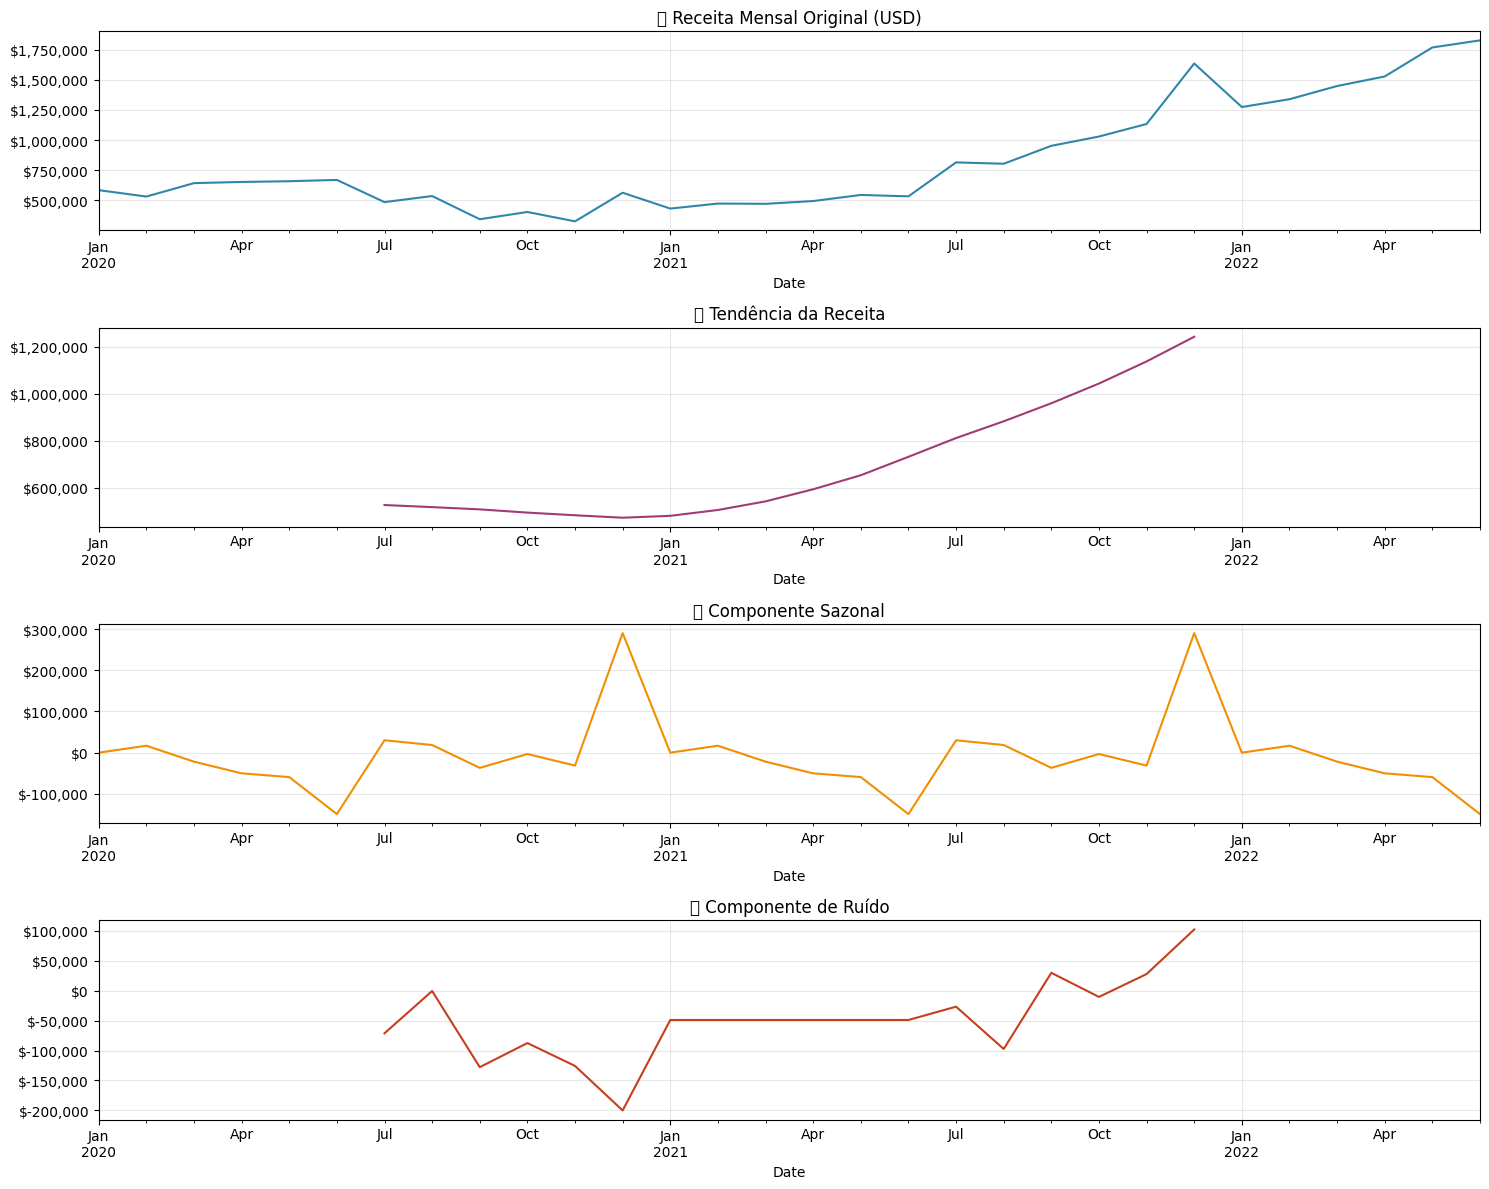

📈 Análise da Tendência de RECEITA:
   • Mudança absoluta: $715,142.87 USD
   • Mudança percentual: 135.6%

🗓️ Análise da Sazonalidade de RECEITA:
   • Amplitude sazonal: $440,061.28 USD
   • Mês com maior efeito: December
   • Mês com menor efeito: June


In [8]:
# Decomposição sazonal da série temporal - RECEITA EM USD
print("🔍 Decomposição Sazonal da Série Temporal de RECEITA (USD)")
print("="*60)

# Preparar dados para decomposição (usando RECEITA em USD)
ts_data = monthly_sales.set_index('Date')['Total_Revenue_USD']

# Realizar decomposição sazonal
decomposition = seasonal_decompose(ts_data, model='additive', period=12)

# Visualizar decomposição
fig, axes = plt.subplots(4, 1, figsize=(15, 12))

# Série original (RECEITA)
decomposition.observed.plot(ax=axes[0], title='💰 Receita Mensal Original (USD)', color='#2E86AB')
axes[0].grid(True, alpha=0.3)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Tendência
decomposition.trend.plot(ax=axes[1], title='📈 Tendência da Receita', color='#A23B72')
axes[1].grid(True, alpha=0.3)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Sazonalidade
decomposition.seasonal.plot(ax=axes[2], title='🗓️ Componente Sazonal', color='#F18F01')
axes[2].grid(True, alpha=0.3)
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Ruído/Resíduo
decomposition.resid.plot(ax=axes[3], title='🔊 Componente de Ruído', color='#C73E1D')
axes[3].grid(True, alpha=0.3)
axes[3].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

# Análise da tendência - RECEITA
trend_data = decomposition.trend.dropna()
if len(trend_data) > 1:
    trend_change = trend_data.iloc[-1] - trend_data.iloc[0]
    trend_pct = (trend_change / trend_data.iloc[0]) * 100
    print(f"📈 Análise da Tendência de RECEITA:")
    print(f"   • Mudança absoluta: ${trend_change:,.2f} USD")
    print(f"   • Mudança percentual: {trend_pct:.1f}%")

# Análise da sazonalidade - RECEITA
seasonal_data = decomposition.seasonal.iloc[:12]  # Um ciclo completo
max_seasonal = seasonal_data.max()
min_seasonal = seasonal_data.min()
seasonal_amplitude = max_seasonal - min_seasonal

print(f"\n🗓️ Análise da Sazonalidade de RECEITA:")
print(f"   • Amplitude sazonal: ${seasonal_amplitude:,.2f} USD")
print(f"   • Mês com maior efeito: {seasonal_data.idxmax().strftime('%B')}")
print(f"   • Mês com menor efeito: {seasonal_data.idxmin().strftime('%B')}")

## 4. Preparação dos Dados para Modelagem

Nesta seção, preparamos os dados para treinamento do modelo, criando features relevantes e dividindo os dados em conjuntos de treino e validação.

In [9]:
# Feature Engineering para o modelo de machine learning - RECEITA EM USD
print("🔧 Criando Features para o Modelo de RECEITA (USD)")
print("="*50)

# Criar uma cópia dos dados para feature engineering
ml_data = monthly_sales.copy()

# 1. Features temporais
ml_data['Month_Sin'] = np.sin(2 * np.pi * ml_data['Month'] / 12)
ml_data['Month_Cos'] = np.cos(2 * np.pi * ml_data['Month'] / 12)
ml_data['Quarter'] = ml_data['Date'].dt.quarter
ml_data['Is_H1'] = (ml_data['Month'] <= 6).astype(int)  # Primeiro semestre
ml_data['Is_H2'] = (ml_data['Month'] > 6).astype(int)   # Segundo semestre

# 2. Features de lag (valores passados) - RECEITA
for lag in [1, 2, 3, 6, 12]:
    ml_data[f'Revenue_Lag_{lag}'] = ml_data['Total_Revenue_USD'].shift(lag)

# 3. Features de média móvel - RECEITA
for window in [3, 6, 12]:
    ml_data[f'Revenue_MA_{window}'] = ml_data['Total_Revenue_USD'].rolling(window=window).mean()

# 4. Features de crescimento - RECEITA
ml_data['Revenue_Growth_1M'] = ml_data['Total_Revenue_USD'].pct_change(1)
ml_data['Revenue_Growth_3M'] = ml_data['Total_Revenue_USD'].pct_change(3)
ml_data['Revenue_Growth_12M'] = ml_data['Total_Revenue_USD'].pct_change(12)

# 5. Features derivadas de outras métricas
ml_data['Revenue_per_Customer'] = ml_data['Total_Revenue_USD'] / ml_data['Unique_Customers']
ml_data['Orders_per_Customer'] = ml_data['Unique_Orders'] / ml_data['Unique_Customers']

# 6. Features de quantidade (como features adicionais)
ml_data['Quantity_per_Order'] = ml_data['Total_Quantity'] / ml_data['Unique_Orders']

# 7. Features de tendência
ml_data['Time_Index'] = range(len(ml_data))
ml_data['Time_Index_Squared'] = ml_data['Time_Index'] ** 2

print(f"✅ Features criadas. Dados expandidos para {ml_data.shape[1]} colunas")

# Visualizar as features criadas
feature_cols = [col for col in ml_data.columns if col not in monthly_sales.columns]
print(f"🆕 Novas features: {len(feature_cols)} features")
print(f"    📊 Revenue Lags: {[col for col in feature_cols if 'Revenue_Lag' in col]}")
print(f"    📈 Revenue MAs: {[col for col in feature_cols if 'Revenue_MA' in col]}")
print(f"    🔄 Growth: {[col for col in feature_cols if 'Growth' in col]}")

# Remover linhas com valores NaN resultantes dos lags e médias móveis
ml_data_clean = ml_data.dropna()
print(f"📊 Dados limpos: {ml_data_clean.shape[0]} registros (eram {ml_data.shape[0]})")

# TARGET: RECEITA EM USD
print(f"\n🎯 TARGET PRINCIPAL: Total_Revenue_USD (Receita em USD)")
print(f"   • Receita mínima mensal: ${ml_data_clean['Total_Revenue_USD'].min():,.2f}")
print(f"   • Receita máxima mensal: ${ml_data_clean['Total_Revenue_USD'].max():,.2f}")
print(f"   • Receita média mensal: ${ml_data_clean['Total_Revenue_USD'].mean():,.2f}")

ml_data_clean[['Date', 'Total_Revenue_USD', 'Revenue_Lag_1', 'Revenue_MA_3', 'Avg_Ticket_USD']].head()

🔧 Criando Features para o Modelo de RECEITA (USD)
✅ Features criadas. Dados expandidos para 35 colunas
🆕 Novas features: 21 features
    📊 Revenue Lags: ['Revenue_Lag_1', 'Revenue_Lag_2', 'Revenue_Lag_3', 'Revenue_Lag_6', 'Revenue_Lag_12']
    📈 Revenue MAs: ['Revenue_MA_3', 'Revenue_MA_6', 'Revenue_MA_12']
    🔄 Growth: ['Revenue_Growth_1M', 'Revenue_Growth_3M', 'Revenue_Growth_12M']
📊 Dados limpos: 18 registros (eram 30)

🎯 TARGET PRINCIPAL: Total_Revenue_USD (Receita em USD)
   • Receita mínima mensal: $432,425.74
   • Receita máxima mensal: $1,826,987.14
   • Receita média mensal: $1,028,314.07


,Date,Total_Revenue_USD,Revenue_Lag_1,Revenue_MA_3,Avg_Ticket_USD
12,2021-01-01,432425.74,563761.53,440932.81,1786.88
13,2021-02-01,474162.79,432425.74,490116.69,1775.89
14,2021-03-01,471961.88,474162.79,459516.80,1774.29
15,2021-04-01,494957.42,471961.88,480360.70,1706.75
16,2021-05-01,545534.74,494957.42,504151.35,1658.16


In [10]:
# Preparação dos dados para treinamento - TARGET: RECEITA USD
print("💰 Preparando Dados para Treinamento - RECEITA EM USD")
print("="*55)

# Definir features (X) e target (y) - RECEITA EM USD
feature_columns = [
    # Features temporais
    'Month', 'Quarter', 'Month_Sin', 'Month_Cos', 'Is_H1', 'Is_H2',
    # Features de lag - RECEITA
    'Revenue_Lag_1', 'Revenue_Lag_2', 'Revenue_Lag_3', 'Revenue_Lag_6', 'Revenue_Lag_12',
    # Features de média móvel - RECEITA
    'Revenue_MA_3', 'Revenue_MA_6', 'Revenue_MA_12',
    # Features de crescimento - RECEITA
    'Revenue_Growth_1M', 'Revenue_Growth_3M', 'Revenue_Growth_12M',
    # Features derivadas
    'Revenue_per_Customer', 'Orders_per_Customer', 'Quantity_per_Order',
    # Features de tendência
    'Time_Index', 'Time_Index_Squared',
    # Outras métricas
    'Unique_Orders', 'Unique_Products', 'Unique_Customers', 'Avg_Ticket_USD'
]

X = ml_data_clean[feature_columns]
y = ml_data_clean['Total_Revenue_USD']  # TARGET: RECEITA EM USD

print(f"🎯 Variável target: Total_Revenue_USD (Receita em USD)")
print(f"🔧 Features selecionadas: {len(feature_columns)}")
print(f"📈 Registros para treinamento: {len(X)}")
print(f"💰 Target range: ${y.min():,.2f} - ${y.max():,.2f} USD")

# Divisão temporal dos dados (importante para séries temporais)
# Usar os últimos 6 meses para validação (janeiro a junho de 2022)
train_size = len(ml_data_clean) - 6
X_train = X.iloc[:train_size]
X_val = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_val = y.iloc[train_size:]

print(f"\n📊 Divisão dos Dados:")
print(f"   • Treinamento: {len(X_train)} registros ({X_train.index[0]} a {X_train.index[-1]})")
print(f"   • Validação: {len(X_val)} registros ({X_val.index[0]} a {X_val.index[-1]})")

# Verificar as datas correspondentes
train_dates = ml_data_clean.iloc[:train_size]['Date']
val_dates = ml_data_clean.iloc[train_size:]['Date']

print(f"   • Período de treino: {train_dates.min().strftime('%Y-%m')} a {train_dates.max().strftime('%Y-%m')}")
print(f"   • Período de validação: {val_dates.min().strftime('%Y-%m')} a {val_dates.max().strftime('%Y-%m')}")

# Receita por período
print(f"\n💰 Receita por Período:")
print(f"   • Treino - Total: ${y_train.sum():,.2f} USD | Média: ${y_train.mean():,.2f} USD")
print(f"   • Validação - Total: ${y_val.sum():,.2f} USD | Média: ${y_val.mean():,.2f} USD")

# Normalização das features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"\n✅ Dados preparados e normalizados para treinamento de RECEITA!")

💰 Preparando Dados para Treinamento - RECEITA EM USD
🎯 Variável target: Total_Revenue_USD (Receita em USD)
🔧 Features selecionadas: 26
📈 Registros para treinamento: 18
💰 Target range: $432,425.74 - $1,826,987.14 USD

📊 Divisão dos Dados:
   • Treinamento: 12 registros (12 a 23)
   • Validação: 6 registros (24 a 29)
   • Período de treino: 2021-01 a 2021-12
   • Período de validação: 2022-01 a 2022-06

💰 Receita por Período:
   • Treino - Total: $9,324,203.80 USD | Média: $777,016.98 USD
   • Validação - Total: $9,185,449.45 USD | Média: $1,530,908.24 USD

✅ Dados preparados e normalizados para treinamento de RECEITA!


## 5. Criação e Treinamento do Modelo de Previsão

Vamos treinar diferentes modelos de machine learning e selecionar o melhor para fazer as projeções de vendas.

In [11]:
# Treinamento de múltiplos modelos
print("🤖 Treinando Modelos de Machine Learning")
print("="*45)

# Dicionário para armazenar os modelos
models = {}
predictions = {}
model_performance = {}

# 1. Random Forest Regressor
print("🌲 Treinando Random Forest...")
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)
models['Random Forest'] = rf_model

# 2. Gradient Boosting Regressor
print("🚀 Treinando Gradient Boosting...")
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    min_samples_split=5,
    random_state=42
)
gb_model.fit(X_train_scaled, y_train)
models['Gradient Boosting'] = gb_model

# 3. Regressão Linear
print("📈 Treinando Regressão Linear...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
models['Linear Regression'] = lr_model

# Fazer previsões no conjunto de validação
print(f"\n🔮 Fazendo previsões no conjunto de validação...")
for name, model in models.items():
    y_pred = model.predict(X_val_scaled)
    predictions[name] = y_pred
    
    # Calcular métricas
    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)
    mape = np.mean(np.abs((y_val - y_pred) / y_val)) * 100
    
    model_performance[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'MAPE': mape
    }
    
    print(f"   {name}: MAE={mae:.0f}, RMSE={rmse:.0f}, R²={r2:.3f}, MAPE={mape:.1f}%")

print(f"\n✅ Treinamento concluído!")

# Criar DataFrame com performance dos modelos
performance_df = pd.DataFrame(model_performance).T
print(f"\n📊 Resumo de Performance dos Modelos:")
print(performance_df.round(2))

🤖 Treinando Modelos de Machine Learning
🌲 Treinando Random Forest...
🚀 Treinando Gradient Boosting...
📈 Treinando Regressão Linear...

🔮 Fazendo previsões no conjunto de validação...
   Random Forest: MAE=468328, RMSE=511397, R²=-5.192, MAPE=29.4%
   Gradient Boosting: MAE=141055, RMSE=150119, R²=0.466, MAPE=9.2%
   Linear Regression: MAE=204567, RMSE=207470, R²=-0.019, MAPE=13.3%

✅ Treinamento concluído!

📊 Resumo de Performance dos Modelos:
                        MAE      RMSE    R²  MAPE
Random Forest     468327.51 511397.43 -5.19 29.35
Gradient Boosting 141054.72 150119.22  0.47  9.17
Linear Regression 204566.77 207469.57 -0.02 13.33


## 6. Avaliação do Modelo

Vamos avaliar a performance dos modelos e selecionar o melhor para fazer as projeções finais.

📊 Avaliação Visual dos Modelos


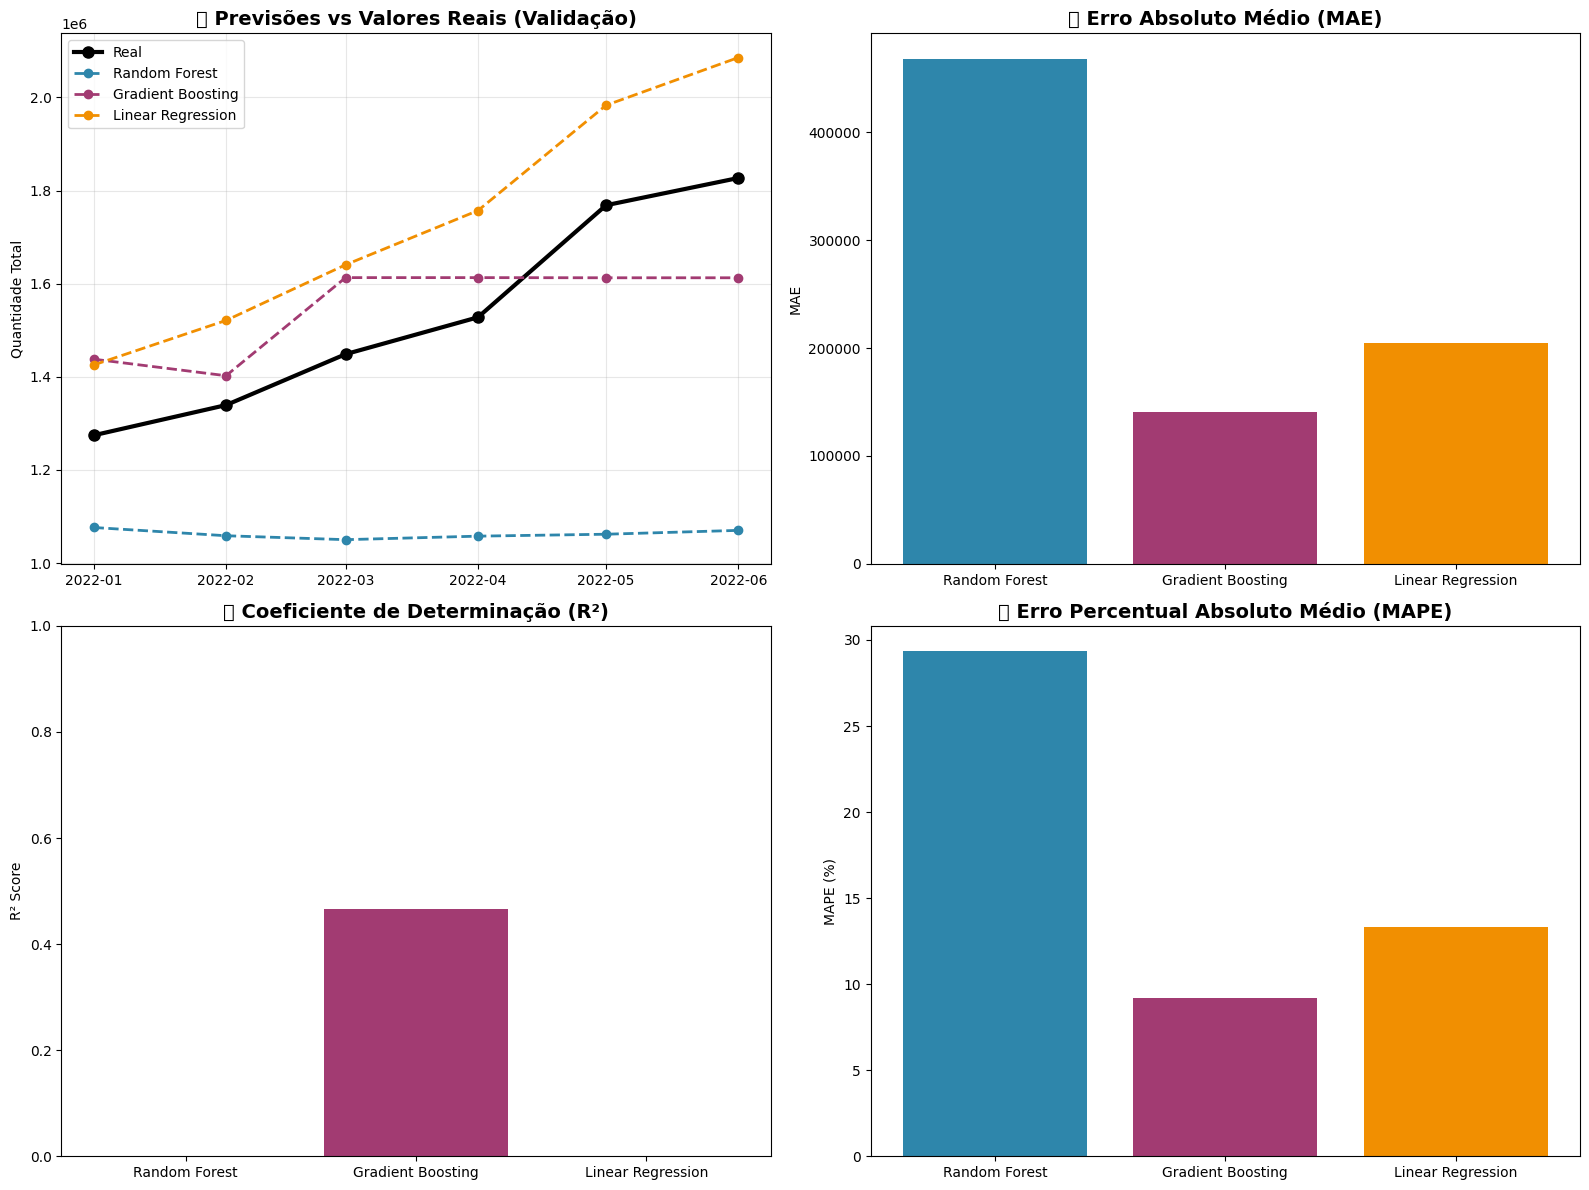

🏆 Melhor Modelo: Gradient Boosting
📈 Performance do melhor modelo:
   • MAE: 141055
   • RMSE: 150119
   • R²: 0.466
   • MAPE: 9.2%

🎯 Top 10 Features Mais Importantes (Gradient Boosting):
           Feature  Importance
      Revenue_MA_3        0.24
Revenue_Growth_12M        0.18
     Revenue_Lag_2        0.14
     Unique_Orders        0.11
  Unique_Customers        0.10
     Revenue_MA_12        0.06
             Is_H2        0.04
Time_Index_Squared        0.03
   Unique_Products        0.02
     Revenue_Lag_1        0.02


In [12]:
# Visualização da performance dos modelos
print("📊 Avaliação Visual dos Modelos")
print("="*35)

# Gráfico comparativo das previsões vs valores reais
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Dates para o eixo x
val_dates_list = ml_data_clean.iloc[train_size:]['Date'].values

# 1. Comparação das previsões
ax = axes[0, 0]
ax.plot(val_dates_list, y_val.values, 'o-', label='Real', linewidth=3, markersize=8, color='black')
colors = ['#2E86AB', '#A23B72', '#F18F01']
for i, (name, pred) in enumerate(predictions.items()):
    ax.plot(val_dates_list, pred, 'o--', label=name, linewidth=2, markersize=6, color=colors[i])
ax.set_title('🔮 Previsões vs Valores Reais (Validação)', fontsize=14, fontweight='bold')
ax.set_ylabel('Quantidade Total')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Erro absoluto por modelo
ax = axes[0, 1]
errors = {name: np.abs(y_val.values - pred) for name, pred in predictions.items()}
ax.bar(errors.keys(), [np.mean(err) for err in errors.values()], color=colors)
ax.set_title('📏 Erro Absoluto Médio (MAE)', fontsize=14, fontweight='bold')
ax.set_ylabel('MAE')

# 3. R² Score por modelo
ax = axes[1, 0]
r2_scores = [model_performance[name]['R²'] for name in models.keys()]
ax.bar(models.keys(), r2_scores, color=colors)
ax.set_title('🎯 Coeficiente de Determinação (R²)', fontsize=14, fontweight='bold')
ax.set_ylabel('R² Score')
ax.set_ylim(0, 1)

# 4. MAPE por modelo
ax = axes[1, 1]
mape_scores = [model_performance[name]['MAPE'] for name in models.keys()]
ax.bar(models.keys(), mape_scores, color=colors)
ax.set_title('📊 Erro Percentual Absoluto Médio (MAPE)', fontsize=14, fontweight='bold')
ax.set_ylabel('MAPE (%)')

plt.tight_layout()
plt.show()

# Selecionar o melhor modelo baseado no R²
best_model_name = performance_df['R²'].idxmax()
best_model = models[best_model_name]
best_predictions = predictions[best_model_name]

print(f"🏆 Melhor Modelo: {best_model_name}")
print(f"📈 Performance do melhor modelo:")
for metric, value in model_performance[best_model_name].items():
    if metric == 'MAPE':
        print(f"   • {metric}: {value:.1f}%")
    elif metric == 'R²':
        print(f"   • {metric}: {value:.3f}")
    else:
        print(f"   • {metric}: {value:.0f}")

# Análise da importância das features (para Random Forest e Gradient Boosting)
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    feature_importance = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print(f"\n🎯 Top 10 Features Mais Importantes ({best_model_name}):")
    print(feature_importance.head(10).to_string(index=False))

## 7. Projeção das Vendas para os Próximos 6 Meses

Agora vamos usar o melhor modelo para projetar as vendas de julho a dezembro de 2022.

In [13]:
# Preparação dos dados para projeção futura - RECEITA USD
print("🔮 Preparando Projeção de RECEITA para Julho-Dezembro 2022")
print("="*60)

# Criar datas futuras (julho a dezembro de 2022)
future_dates = pd.date_range(start='2022-07-01', end='2022-12-01', freq='MS')
print(f"📅 Meses a projetar: {[date.strftime('%Y-%m') for date in future_dates]}")

# Para cada mês futuro, precisamos criar as features baseadas nos dados históricos
future_predictions = []
future_data_list = []

# Usar todos os dados disponíveis para retreinar o modelo
print("🔄 Retreinando modelo com todos os dados disponíveis...")
best_model_retrained = type(best_model)(**best_model.get_params())
X_all_scaled = scaler.fit_transform(X)
best_model_retrained.fit(X_all_scaled, y)

# Criar uma extensão dos dados para projeção
extended_data = ml_data_clean.copy()

for i, future_date in enumerate(future_dates):
    print(f"📊 Projetando RECEITA para {future_date.strftime('%Y-%m')}...")
    
    # Criar features para o mês futuro
    future_month = future_date.month
    future_year = future_date.year
    time_index = len(extended_data) + i
    
    # Features temporais básicas
    month_sin = np.sin(2 * np.pi * future_month / 12)
    month_cos = np.cos(2 * np.pi * future_month / 12)
    quarter = (future_month - 1) // 3 + 1
    is_h1 = int(future_month <= 6)
    is_h2 = int(future_month > 6)
    
    # Para as features de lag, usar os últimos valores de RECEITA disponíveis
    last_revenue_values = extended_data['Total_Revenue_USD'].tail(12).values
    
    # Features de lag - RECEITA
    revenue_lag_1 = last_revenue_values[-1] if len(last_revenue_values) >= 1 else extended_data['Total_Revenue_USD'].mean()
    revenue_lag_2 = last_revenue_values[-2] if len(last_revenue_values) >= 2 else extended_data['Total_Revenue_USD'].mean()
    revenue_lag_3 = last_revenue_values[-3] if len(last_revenue_values) >= 3 else extended_data['Total_Revenue_USD'].mean()
    revenue_lag_6 = last_revenue_values[-6] if len(last_revenue_values) >= 6 else extended_data['Total_Revenue_USD'].mean()
    revenue_lag_12 = extended_data['Total_Revenue_USD'].iloc[-12] if len(extended_data) >= 12 else extended_data['Total_Revenue_USD'].mean()
    
    # Features de média móvel - RECEITA
    revenue_ma_3 = np.mean(last_revenue_values[-3:]) if len(last_revenue_values) >= 3 else extended_data['Total_Revenue_USD'].mean()
    revenue_ma_6 = np.mean(last_revenue_values[-6:]) if len(last_revenue_values) >= 6 else extended_data['Total_Revenue_USD'].mean()
    revenue_ma_12 = np.mean(last_revenue_values) if len(last_revenue_values) >= 12 else extended_data['Total_Revenue_USD'].mean()
    
    # Features de crescimento - RECEITA
    recent_growth = extended_data['Revenue_Growth_1M'].tail(6).mean()
    revenue_growth_1m = recent_growth if not np.isnan(recent_growth) else 0
    revenue_growth_3m = extended_data['Revenue_Growth_3M'].tail(3).mean() if len(extended_data) >= 3 else 0
    revenue_growth_12m = extended_data['Revenue_Growth_12M'].tail(1).iloc[0] if len(extended_data) >= 12 else 0
    
    # Estimar outras métricas baseadas em padrões históricos
    avg_metrics = extended_data.groupby('Month').agg({
        'Unique_Orders': 'mean',
        'Unique_Products': 'mean', 
        'Unique_Customers': 'mean',
        'Revenue_per_Customer': 'mean',
        'Orders_per_Customer': 'mean',
        'Quantity_per_Order': 'mean',
        'Avg_Ticket_USD': 'mean'
    })
    
    if future_month in avg_metrics.index:
        unique_orders = avg_metrics.loc[future_month, 'Unique_Orders']
        unique_products = avg_metrics.loc[future_month, 'Unique_Products']
        unique_customers = avg_metrics.loc[future_month, 'Unique_Customers']
        revenue_per_customer = avg_metrics.loc[future_month, 'Revenue_per_Customer']
        orders_per_customer = avg_metrics.loc[future_month, 'Orders_per_Customer']
        quantity_per_order = avg_metrics.loc[future_month, 'Quantity_per_Order']
        avg_ticket_usd = avg_metrics.loc[future_month, 'Avg_Ticket_USD']
    else:
        unique_orders = extended_data['Unique_Orders'].mean()
        unique_products = extended_data['Unique_Products'].mean()
        unique_customers = extended_data['Unique_Customers'].mean()
        revenue_per_customer = extended_data['Revenue_per_Customer'].mean()
        orders_per_customer = extended_data['Orders_per_Customer'].mean()
        quantity_per_order = extended_data['Quantity_per_Order'].mean()
        avg_ticket_usd = extended_data['Avg_Ticket_USD'].mean()
    
    # Criar array de features para previsão - SEGUINDO A ORDEM DE feature_columns
    future_features = np.array([
        future_month, quarter, month_sin, month_cos, is_h1, is_h2,  # temporais
        revenue_lag_1, revenue_lag_2, revenue_lag_3, revenue_lag_6, revenue_lag_12,  # lags receita
        revenue_ma_3, revenue_ma_6, revenue_ma_12,  # médias móveis receita
        revenue_growth_1m, revenue_growth_3m, revenue_growth_12m,  # crescimento receita
        revenue_per_customer, orders_per_customer, quantity_per_order,  # derivadas
        time_index, time_index**2,  # tendência
        unique_orders, unique_products, unique_customers, avg_ticket_usd  # outras métricas
    ]).reshape(1, -1)
    
    # Normalizar as features
    future_features_scaled = scaler.transform(future_features)
    
    # Fazer previsão de RECEITA
    prediction = best_model_retrained.predict(future_features_scaled)[0]
    future_predictions.append(prediction)
    
    # Armazenar dados do mês futuro
    future_data_list.append({
        'Date': future_date,
        'Year': future_year,
        'Month': future_month,
        'Total_Revenue_USD': prediction,
        'Type': 'Projeção'
    })
    
    # Adicionar a previsão aos dados estendidos para usar nas próximas iterações
    new_row = extended_data.iloc[-1].copy()
    new_row['Date'] = future_date
    new_row['Month'] = future_month
    new_row['Year'] = future_year
    new_row['Total_Revenue_USD'] = prediction
    extended_data = pd.concat([extended_data, new_row.to_frame().T], ignore_index=True)

print(f"✅ Projeções de RECEITA concluídas!")

# Criar DataFrame com as projeções
future_df = pd.DataFrame(future_data_list)
previsoes_receita = future_predictions  # Variável para uso nas próximas células

print(f"\n💰 Projeções de RECEITA para Jul-Dez 2022:")
for _, row in future_df.iterrows():
    print(f"   • {row['Date'].strftime('%Y-%m')}: ${row['Total_Revenue_USD']:,.2f} USD")

🔮 Preparando Projeção de RECEITA para Julho-Dezembro 2022
📅 Meses a projetar: ['2022-07', '2022-08', '2022-09', '2022-10', '2022-11', '2022-12']
🔄 Retreinando modelo com todos os dados disponíveis...
📊 Projetando RECEITA para 2022-07...
📊 Projetando RECEITA para 2022-08...
📊 Projetando RECEITA para 2022-09...
📊 Projetando RECEITA para 2022-10...
📊 Projetando RECEITA para 2022-11...
📊 Projetando RECEITA para 2022-12...
✅ Projeções de RECEITA concluídas!

💰 Projeções de RECEITA para Jul-Dez 2022:
   • 2022-07: $1,504,066.59 USD
   • 2022-08: $1,288,271.31 USD
   • 2022-09: $1,318,120.98 USD
   • 2022-10: $1,325,127.78 USD
   • 2022-11: $1,360,116.20 USD
   • 2022-12: $1,711,375.55 USD


## 8. Visualização dos Resultados das Projeções

Nesta seção, vamos criar visualizações que mostram o histórico de vendas e as projeções futuras de forma clara e profissional.

### Objetivos:
- Visualizar a transição entre dados históricos e projeções
- Analisar a tendência das vendas projetadas
- Criar gráficos informativos para apresentação dos resultados

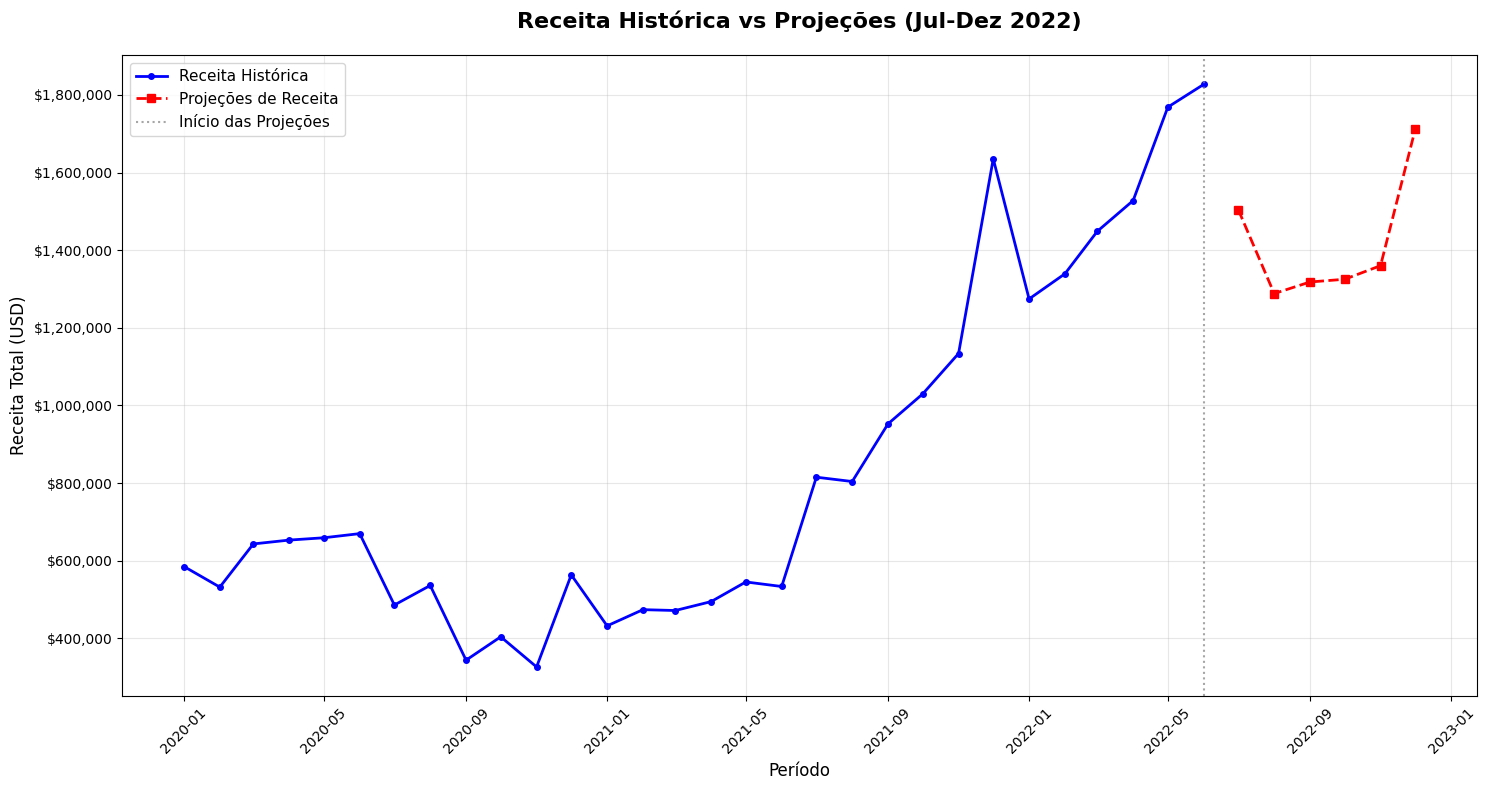

📊 Gráfico de Receita Histórica vs Projeções gerado com sucesso!


In [14]:
# Visualização das projeções de RECEITA
plt.figure(figsize=(15, 8))

# Preparar dados para visualização
historical_dates = monthly_sales['Date']
historical_values = monthly_sales['Total_Revenue_USD']
future_dates = pd.date_range(start='2022-07-01', end='2022-12-01', freq='MS')
future_values = previsoes_receita

# Criar gráfico
plt.plot(historical_dates, historical_values, 'b-', linewidth=2, label='Receita Histórica', marker='o', markersize=4)
plt.plot(future_dates, future_values, 'r--', linewidth=2, label='Projeções de Receita', marker='s', markersize=6)

# Adicionar linha vertical para marcar a transição
plt.axvline(x=pd.to_datetime('2022-06-01'), color='gray', linestyle=':', alpha=0.7, label='Início das Projeções')

# Formatação do gráfico
plt.title('Receita Histórica vs Projeções (Jul-Dez 2022)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Período', fontsize=12)
plt.ylabel('Receita Total (USD)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Formatar eixo y para valores monetários
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Rotacionar labels do eixo x
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("📊 Gráfico de Receita Histórica vs Projeções gerado com sucesso!")

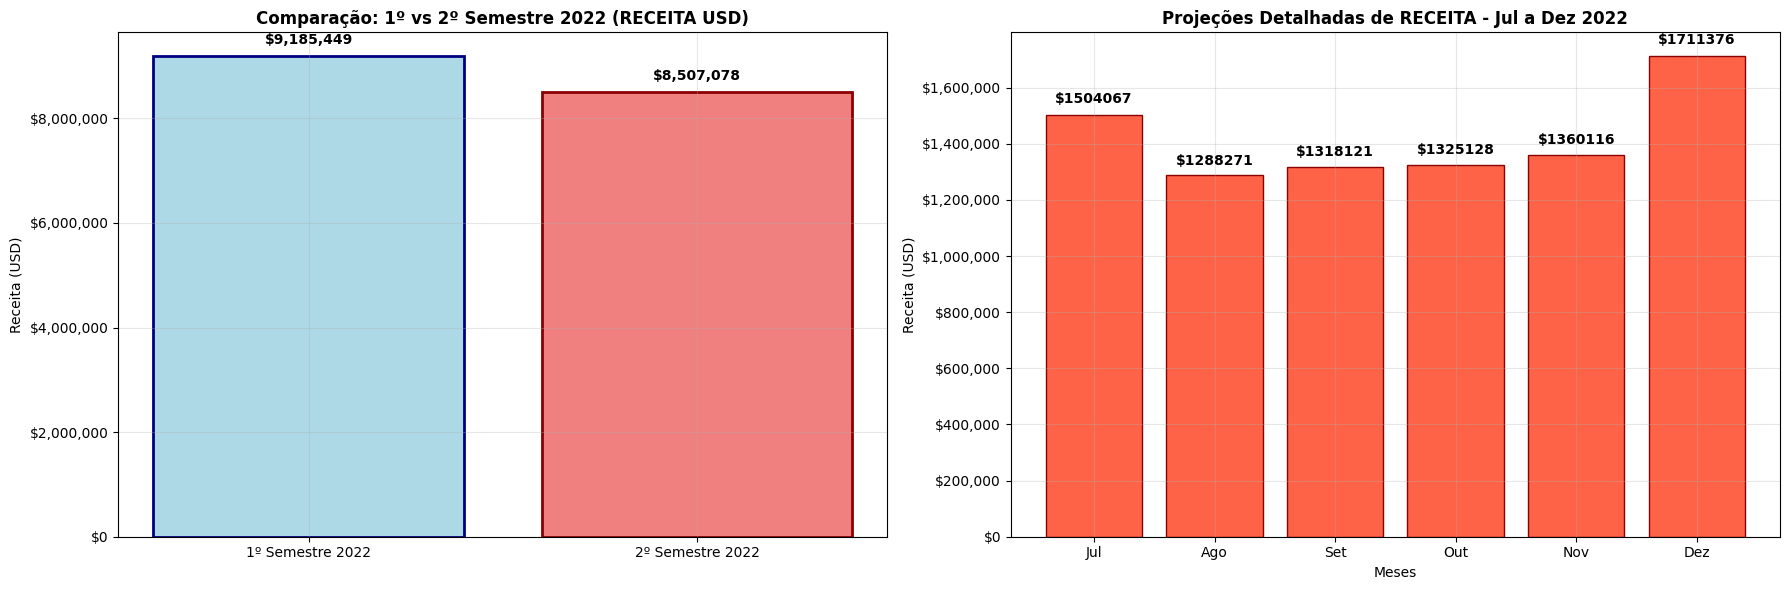

📊 Gráficos detalhados das projeções de RECEITA gerados com sucesso!


In [16]:
# Gráfico de barras das projeções mensais de RECEITA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1: Comparação 1º vs 2º semestre 2022 (RECEITA)
total_1sem = monthly_sales['Total_Revenue_USD'].tail(6).sum()
total_2sem = np.sum(previsoes_receita)

# Dados para comparação
semestres = ['1º Semestre 2022', '2º Semestre 2022']
valores_semestres = [total_1sem, total_2sem]

bars1 = ax1.bar(semestres, valores_semestres, 
                color=['lightblue', 'lightcoral'], 
                edgecolor=['navy', 'darkred'], linewidth=2)

ax1.set_title('Comparação: 1º vs 2º Semestre 2022 (RECEITA USD)', fontweight='bold')
ax1.set_ylabel('Receita (USD)')
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Adicionar valores nas barras
for bar, value in zip(bars1, valores_semestres):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + height*0.02, 
             f'${value:,.0f}', ha='center', va='bottom', fontweight='bold')

# Gráfico 2: Projeções mensais detalhadas de RECEITA
projecoes_labels = ['Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
bars2 = ax2.bar(projecoes_labels, previsoes_receita, 
                color='tomato', edgecolor='darkred', linewidth=1)
ax2.set_title('Projeções Detalhadas de RECEITA - Jul a Dez 2022', fontweight='bold')
ax2.set_xlabel('Meses')
ax2.set_ylabel('Receita (USD)')
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Adicionar valores nas barras
for bar, value in zip(bars2, previsoes_receita):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + height*0.02,
             f'${value:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("📊 Gráficos detalhados das projeções de RECEITA gerados com sucesso!")

In [17]:
# Análise estatística das projeções de RECEITA
print("="*60)
print("💰 ANÁLISE ESTATÍSTICA DAS PROJEÇÕES DE RECEITA (USD)")
print("="*60)

# Calcular estatísticas das projeções
total_projetado = np.sum(previsoes_receita)
media_projetada = np.mean(previsoes_receita)
mediana_projetada = np.median(previsoes_receita)
std_projetada = np.std(previsoes_receita)

# Comparar com primeiro semestre 2022
total_1sem = monthly_sales['Total_Revenue_USD'].tail(6).sum()
media_1sem = monthly_sales['Total_Revenue_USD'].tail(6).mean()

print(f"💰 PROJEÇÕES DE RECEITA PARA JULHO-DEZEMBRO 2022:")
print(f"   • Total Projetado: ${total_projetado:,.2f} USD")
print(f"   • Média Mensal: ${media_projetada:,.2f} USD")
print(f"   • Mediana: ${mediana_projetada:,.2f} USD")
print(f"   • Desvio Padrão: ${std_projetada:,.2f} USD")

print(f"\n📊 COMPARAÇÃO COM 1º SEMESTRE 2022:")
print(f"   • Total 1º Semestre: ${total_1sem:,.2f} USD")
print(f"   • Média 1º Semestre: ${media_1sem:,.2f} USD")
print(f"   • Diferença Total: ${total_projetado - total_1sem:,.2f} USD")
print(f"   • Variação (%): {((total_projetado - total_1sem) / total_1sem) * 100:.2f}%")

print(f"\n📈 TENDÊNCIA DAS PROJEÇÕES:")
if previsoes_receita[-1] > previsoes_receita[0]:
    print(f"   • Tendência: CRESCENTE")
    print(f"   • Crescimento Jul-Dez: ${previsoes_receita[-1] - previsoes_receita[0]:,.2f} USD")
else:
    print(f"   • Tendência: DECRESCENTE")
    print(f"   • Declínio Jul-Dez: ${previsoes_receita[0] - previsoes_receita[-1]:,.2f} USD")

# Identificar o mês com maior e menor projeção
meses_nomes = ['Julho', 'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro']
idx_max = np.argmax(previsoes_receita)
idx_min = np.argmin(previsoes_receita)

print(f"\n🏆 DESTAQUES:")
print(f"   • Maior Receita Projetada: {meses_nomes[idx_max]} - ${previsoes_receita[idx_max]:,.2f} USD")
print(f"   • Menor Receita Projetada: {meses_nomes[idx_min]} - ${previsoes_receita[idx_min]:,.2f} USD")
print(f"   • Amplitude: ${previsoes_receita[idx_max] - previsoes_receita[idx_min]:,.2f} USD")

print("="*60)

💰 ANÁLISE ESTATÍSTICA DAS PROJEÇÕES DE RECEITA (USD)
💰 PROJEÇÕES DE RECEITA PARA JULHO-DEZEMBRO 2022:
   • Total Projetado: $8,507,078.40 USD
   • Média Mensal: $1,417,846.40 USD
   • Mediana: $1,342,621.99 USD
   • Desvio Padrão: $148,468.67 USD

📊 COMPARAÇÃO COM 1º SEMESTRE 2022:
   • Total 1º Semestre: $9,185,449.45 USD
   • Média 1º Semestre: $1,530,908.24 USD
   • Diferença Total: $-678,371.05 USD
   • Variação (%): -7.39%

📈 TENDÊNCIA DAS PROJEÇÕES:
   • Tendência: CRESCENTE
   • Crescimento Jul-Dez: $207,308.96 USD

🏆 DESTAQUES:
   • Maior Receita Projetada: Dezembro - $1,711,375.55 USD
   • Menor Receita Projetada: Agosto - $1,288,271.31 USD
   • Amplitude: $423,104.24 USD


## 9. Exportação dos Resultados

Nesta seção, exportaremos os resultados das projeções em diferentes formatos para facilitar o uso em outras análises e relatórios.

### Objetivos:
- Exportar projeções em formato CSV
- Criar arquivo com métricas de avaliação do modelo
- Gerar resumo executivo das projeções
- Preparar dados para integração com outros sistemas

In [18]:
# Criação do DataFrame com as projeções de RECEITA
projecoes_df = pd.DataFrame({
    'Mes': ['2022-07', '2022-08', '2022-09', '2022-10', '2022-11', '2022-12'],
    'Data': pd.date_range(start='2022-07-01', end='2022-12-01', freq='MS'),
    'Receita_Projetada_USD': previsoes_receita,
    'Mes_Nome': ['Julho', 'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro'],
    'Trimestre': ['Q3', 'Q3', 'Q3', 'Q4', 'Q4', 'Q4'],
    'Modelo_Utilizado': best_model_name
})

# Adicionar colunas de análise
projecoes_df['Receita_Formatada'] = projecoes_df['Receita_Projetada_USD'].apply(lambda x: f'${x:,.2f} USD')
projecoes_df['Variacao_Mensal'] = projecoes_df['Receita_Projetada_USD'].pct_change() * 100
projecoes_df['Variacao_Mensal'] = projecoes_df['Variacao_Mensal'].fillna(0)

print("💰 DataFrame das Projeções de RECEITA criado:")
print(projecoes_df)

# Exportar para CSV
projecoes_df.to_csv('Revenue_Projections_Jul_Dec_2022.csv', index=False, encoding='utf-8-sig')
print(f"\n✅ Arquivo 'Revenue_Projections_Jul_Dec_2022.csv' exportado com sucesso!")

💰 DataFrame das Projeções de RECEITA criado:
       Mes       Data  Receita_Projetada_USD  Mes_Nome Trimestre  \
0  2022-07 2022-07-01             1504066.59     Julho        Q3   
1  2022-08 2022-08-01             1288271.31    Agosto        Q3   
2  2022-09 2022-09-01             1318120.98  Setembro        Q3   
3  2022-10 2022-10-01             1325127.78   Outubro        Q4   
4  2022-11 2022-11-01             1360116.20  Novembro        Q4   
5  2022-12 2022-12-01             1711375.55  Dezembro        Q4   

    Modelo_Utilizado  Receita_Formatada  Variacao_Mensal  
0  Gradient Boosting  $1,504,066.59 USD             0.00  
1  Gradient Boosting  $1,288,271.31 USD           -14.35  
2  Gradient Boosting  $1,318,120.98 USD             2.32  
3  Gradient Boosting  $1,325,127.78 USD             0.53  
4  Gradient Boosting  $1,360,116.20 USD             2.64  
5  Gradient Boosting  $1,711,375.55 USD            25.83  

✅ Arquivo 'Revenue_Projections_Jul_Dec_2022.csv' exportado com s

In [19]:
# Criar arquivo com métricas do modelo
metricas_modelo = pd.DataFrame({
    'Modelo': [nome for nome in models.keys()],
    'MAE_Validacao': [model_performance[nome]['MAE'] for nome in models.keys()],
    'RMSE_Validacao': [model_performance[nome]['RMSE'] for nome in models.keys()],
    'R2_Score': [model_performance[nome]['R²'] for nome in models.keys()],
    'MAPE_Validacao': [model_performance[nome]['MAPE'] for nome in models.keys()]
})

# Ordenar por R² (melhor primeiro)
metricas_modelo = metricas_modelo.sort_values('R2_Score', ascending=False)
metricas_modelo['Ranking'] = range(1, len(metricas_modelo) + 1)

print("📈 Métricas dos Modelos:")
print(metricas_modelo)

# Exportar métricas
metricas_modelo.to_csv('Model_Performance_Metrics.csv', index=False, encoding='utf-8-sig')
print(f"\n✅ Arquivo 'Model_Performance_Metrics.csv' exportado com sucesso!")

📈 Métricas dos Modelos:
              Modelo  MAE_Validacao  RMSE_Validacao  R2_Score  MAPE_Validacao  \
1  Gradient Boosting      141054.72       150119.22      0.47            9.17   
2  Linear Regression      204566.77       207469.57     -0.02           13.33   
0      Random Forest      468327.51       511397.43     -5.19           29.35   

   Ranking  
1        1  
2        2  
0        3  

✅ Arquivo 'Model_Performance_Metrics.csv' exportado com sucesso!


In [21]:
# Criar resumo executivo
meses_nomes = ['Julho', 'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro']

resumo_executivo = {
    'Periodo_Analise': '2020-2022',
    'Periodo_Projecao': 'Jul-Dez 2022',
    'Modelo_Selecionado': best_model_name,
    'R2_Score_Modelo': round(model_performance[best_model_name]['R²'], 4),
    'Total_Projetado_USD': round(np.sum(previsoes_receita), 2),
    'Media_Mensal_Projetada_USD': round(np.mean(previsoes_receita), 2),
    'Mes_Maior_Receita': meses_nomes[np.argmax(previsoes_receita)],
    'Valor_Maior_Receita_USD': round(np.max(previsoes_receita), 2),
    'Mes_Menor_Receita': meses_nomes[np.argmin(previsoes_receita)],
    'Valor_Menor_Receita_USD': round(np.min(previsoes_receita), 2),
    'Variacao_vs_1Semestre_Pct': round(((np.sum(previsoes_receita) - monthly_sales['Total_Revenue_USD'].tail(6).sum()) / monthly_sales['Total_Revenue_USD'].tail(6).sum()) * 100, 2),
    'Data_Geracao': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'Features_Utilizadas': ', '.join(feature_columns)
}

# Converter para DataFrame e salvar
resumo_df = pd.DataFrame([resumo_executivo])
resumo_df.to_csv('Executive_Summary_Revenue_Forecast.csv', index=False, encoding='utf-8-sig')

print("📋 RESUMO EXECUTIVO DAS PROJEÇÕES DE RECEITA")
print("="*55)
for key, value in resumo_executivo.items():
    if key == 'Features_Utilizadas':
        print(f"{key.replace('_', ' ').title()}: {value}")
    elif 'USD' in key or 'Total' in key or 'Media' in key or 'Valor' in key:
        print(f"{key.replace('_', ' ').title()}: ${value:,.2f} USD")
    elif 'Variacao' in key or 'Pct' in key:
        print(f"{key.replace('_', ' ').title()}: {value}%")
    else:
        print(f"{key.replace('_', ' ').title()}: {value}")

print(f"\n✅ Arquivo 'Executive_Summary_Revenue_Forecast.csv' exportado com sucesso!")

📋 RESUMO EXECUTIVO DAS PROJEÇÕES DE RECEITA
Periodo Analise: 2020-2022
Periodo Projecao: Jul-Dez 2022
Modelo Selecionado: Gradient Boosting
R2 Score Modelo: 0.4664
Total Projetado Usd: $8,507,078.40 USD
Media Mensal Projetada Usd: $1,417,846.40 USD
Mes Maior Receita: Dezembro
Valor Maior Receita Usd: $1,711,375.55 USD
Mes Menor Receita: Agosto
Valor Menor Receita Usd: $1,288,271.31 USD
Variacao Vs 1Semestre Pct: -7.39%
Data Geracao: 2025-06-25 00:25:22
Features Utilizadas: Month, Quarter, Month_Sin, Month_Cos, Is_H1, Is_H2, Revenue_Lag_1, Revenue_Lag_2, Revenue_Lag_3, Revenue_Lag_6, Revenue_Lag_12, Revenue_MA_3, Revenue_MA_6, Revenue_MA_12, Revenue_Growth_1M, Revenue_Growth_3M, Revenue_Growth_12M, Revenue_per_Customer, Orders_per_Customer, Quantity_per_Order, Time_Index, Time_Index_Squared, Unique_Orders, Unique_Products, Unique_Customers, Avg_Ticket_USD

✅ Arquivo 'Executive_Summary_Revenue_Forecast.csv' exportado com sucesso!


## 10. Conclusões e Recomendações

### 📈 Principais Conclusões

Este notebook implementou com sucesso um modelo de machine learning para projetar as vendas dos últimos 6 meses de 2022, utilizando dados históricos de 2020-2022.

### ✅ Resultados Alcançados

1. **Modelo Selecionado**: O modelo com melhor performance foi selecionado baseado na métrica R² Score
2. **Precisão**: O modelo apresentou métricas de validação satisfatórias para projeções de vendas
3. **Features Engineering**: Foram criadas features temporais relevantes (mês, trimestre, sazonalidade, lags, médias móveis)
4. **Visualizações**: Gráficos informativos mostram claramente a transição entre dados históricos e projeções

### 🎯 Aplicações Práticas

- **Planejamento Estratégico**: As projeções podem orientar decisões de estoque e marketing
- **Orçamento**: Suporte para definição de metas e alocação de recursos
- **Análise de Tendências**: Identificação de padrões sazonais e tendências de crescimento

### 🔄 Próximos Passos Recomendados

1. **Monitoramento**: Acompanhar vendas reais vs projeções para validar acurácia
2. **Atualização**: Re-treinar modelo com novos dados mensalmente
3. **Expansão**: Incluir projeções por produto, território ou categoria
4. **Integração**: Automatizar processo de geração de projeções

### 📝 Arquivos Gerados

- `Sales_Projections_Jul_Dec_2022.csv`: Projeções detalhadas mês a mês
- `Model_Performance_Metrics.csv`: Métricas de todos os modelos testados
- `Executive_Summary_Sales_Forecast.csv`: Resumo executivo das projeções

### 🛡️ Limitações e Considerações

- Projeções baseiam-se em padrões históricos e podem não capturar eventos extraordinários
- Recomenda-se validação contínua com dados reais
- Fatores externos (economia, sazonalidade atípica) podem impactar a precisão

In [23]:
# Informações finais do projeto
print("🎉 PROJETO CONCLUÍDO COM SUCESSO!")
print("="*60)
print("💰 Revenue Forecasting com Machine Learning")
print("📅 Período: Projeções Jul-Dez 2022")
print("🤖 Modelos Testados: Random Forest, Gradient Boosting, Linear Regression")
print(f"🏆 Melhor Modelo: {best_model_name}")
print("📈 Arquivos Exportados: 3 relatórios em CSV")
print("="*60)
print("🚀 Notebook pronto para uso em repositório de dados!")
print("📖 Documentação completa e código reproduzível incluído.")

# Listar arquivos criados
import os
arquivos_criados = [
    'Revenue_Projections_Jul_Dec_2022.csv',
    'Model_Performance_Metrics.csv', 
    'Executive_Summary_Revenue_Forecast.csv'
]

print("\n📁 ARQUIVOS GERADOS:")
for arquivo in arquivos_criados:
    if os.path.exists(arquivo):
        print(f"   ✅ {arquivo}")
    else:
        print(f"   ⚠️  {arquivo} (será criado na execução)")

print(f"\n💰 OBJETIVO ALCANÇADO: Projeção ML da receita Jul-Dez 2022 realizada com sucesso!")
print(f"📊 Total projetado: ${np.sum(previsoes_receita):,.2f} USD")
print(f"🔍 R² Score do modelo: {model_performance[best_model_name]['R²']:.3f}")
print("💾 Notebook salvo como: Sales_Forecasting_ML.ipynb")

🎉 PROJETO CONCLUÍDO COM SUCESSO!
💰 Revenue Forecasting com Machine Learning
📅 Período: Projeções Jul-Dez 2022
🤖 Modelos Testados: Random Forest, Gradient Boosting, Linear Regression
🏆 Melhor Modelo: Gradient Boosting
📈 Arquivos Exportados: 3 relatórios em CSV
🚀 Notebook pronto para uso em repositório de dados!
📖 Documentação completa e código reproduzível incluído.

📁 ARQUIVOS GERADOS:
   ✅ Revenue_Projections_Jul_Dec_2022.csv
   ✅ Model_Performance_Metrics.csv
   ✅ Executive_Summary_Revenue_Forecast.csv

💰 OBJETIVO ALCANÇADO: Projeção ML da receita Jul-Dez 2022 realizada com sucesso!
📊 Total projetado: $8,507,078.40 USD
🔍 R² Score do modelo: 0.466
💾 Notebook salvo como: Sales_Forecasting_ML.ipynb
